# Exam 2025

**Table of contents**<a id='toc0_'></a>    
- 1. [Problem 1: Danish House Prices](#toc1_)    
  - 1.1. [Question 1](#toc1_1_)    
  - 1.2. [Question 2](#toc1_2_)    
  - 1.3. [Question 3](#toc1_3_)    
  - 1.4. [Question 4](#toc1_4_)    
- 2. [Problem 2: Exchange Economy](#toc2_)    
  - 2.1. [Question 1](#toc2_1_)    
  - 2.2. [Question 2](#toc2_2_)    
  - 2.3. [Question 3](#toc2_3_)    
  - 2.4. [Question 4](#toc2_4_)    
  - 2.5. [Question 6](#toc2_5_)    
- 3. [Problem 3: AS-AD Model](#toc3_)    
  - 3.1. [Question 1](#toc3_1_)    
  - 3.2. [Question 2](#toc3_2_)    
  - 3.3. [Question 3](#toc3_3_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## 1. <a id='toc1_'></a>[Problem 1: Danish House Prices](#toc0_)

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

# APIs
from dstapi import DstApi

# plotting
import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

### 1.1. <a id='toc1_1_'></a>[Question 1](#toc0_)

In [2]:
EJ56 = DstApi('EJ56')
EJ56.tablesummary(language='en')

Table EJ56: Price index for sales of property by region, category of real property, unit and time
Last update: 2026-01-08T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,OMRÅDE,17,000,All Denmark,11,Province Nordjylland,False
1,EJENDOMSKATE,3,0111,One-family houses,2103,"Owner-occupied flats, total",False
2,TAL,3,100,Index,310,Percentage change compared to same quarter the...,False
3,Tid,135,1992K1,1992Q1,2025K3,2025Q3,True


In [3]:
# a. set download parameters
params = {
    'table': 'EJ56',
    'format': 'BULK', # semicolon separated file
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['*']},
        {'code': 'EJENDOMSKATE', 'values': ['0111']},
        {'code': 'TAL', 'values': ['100']},
        {'code': 'Tid', 'values': ['*']}, # '*' is everything
        ]
    }

# b. download
EJ56 = DstApi('EJ56').get_data(params=params)

# c. display
EJ56.head(5)

,OMRÅDE,EJENDOMSKATE,TAL,TID,INDHOLD
0,All Denmark,One-family houses,Index,2009Q3,68.3
1,Province Byen København,One-family houses,Index,2009Q3,47.9
2,Province Københavns omegn,One-family houses,Index,2009Q3,51.4
3,Province Nordsjælland,One-family houses,Index,2009Q3,58.0
4,Province Bornholm,One-family houses,Index,2009Q3,73.5


Clean:

In [4]:
# a. rename columns
EJ56 = EJ56.rename(columns={'OMRÅDE':'province','TID':'time','INDHOLD':'house_price_index'})

# b. keep only provinces
I = EJ56.province.str.contains('Province')
EJ56 = EJ56[I]
EJ56.province = EJ56.province.str.replace('Province ','')

# c. drop
EJ56 = EJ56.drop(columns=['EJENDOMSKATE','TAL'])

# c. house price index to float
EJ56.house_price_index = EJ56.house_price_index.str.replace('..','nan')
EJ56.house_price_index = EJ56.house_price_index.astype(float)

# d. date
def convert_date(time):
    return f'{time[:4]}-{int(time[5])*3-2:02d}-01'

EJ56.time = EJ56.time.apply(convert_date)
EJ56.time = pd.to_datetime(EJ56.time)

# e. drop any province with nan
I = EJ56.groupby('province').house_price_index.transform(lambda x: x.isna().any())
EJ56 = EJ56[~I]

# f. sort and index
EJ56 = EJ56.sort_values(['province','time'])

EJ56.head(5)

,province,time,house_price_index
18,Byen København,1992-01-01,12.5
1371,Byen København,1992-04-01,12.7
35,Byen København,1992-07-01,12.7
52,Byen København,1992-10-01,12.0
1735,Byen København,1993-01-01,12.0


Re-index house price index:

In [5]:
EJ56.house_price_index = EJ56.groupby('province').house_price_index.transform(lambda x: x / x.iloc[0] * 100)

In [6]:
EJ56.head(5)

,province,time,house_price_index
18,Byen København,1992-01-01,100.0
1371,Byen København,1992-04-01,101.6
35,Byen København,1992-07-01,101.6
52,Byen København,1992-10-01,96.0
1735,Byen København,1993-01-01,96.0


Nominal plot:

In [7]:
EJ56 = EJ56.set_index(['province','time'])

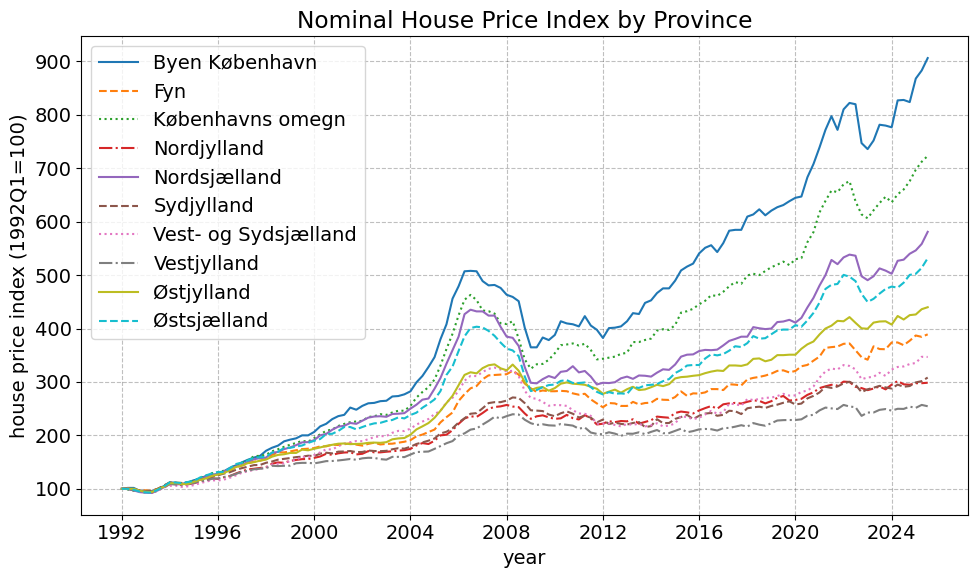

In [8]:
fig = plt.figure(figsize=(10,6))

ax = fig.add_subplot(1,1,1)

lss = ['-','--',':','-.']
for i, province in enumerate(EJ56.index.levels[0]):
    ax.plot(EJ56.xs(province).index,EJ56.xs(province).house_price_index,label=province, linestyle=lss[i % len(lss)])

ax.legend()
ax.set_ylabel('house price index (1992Q1=100)')
ax.set_xlabel('year')
ax.set_title('Nominal House Price Index by Province')

fig.tight_layout()

Ranking:

In [9]:
hp_growth = EJ56.groupby('province').house_price_index.apply(lambda x: x.iloc[-1] / x.iloc[0] - 1)
hp_growth = hp_growth.sort_values(ascending=False)
hp_growth

province
Byen København          8.064000
Københavns omegn        6.233766
Nordsjælland            4.810526
Østsjælland             4.317073
Østjylland              3.399177
Fyn                     2.891304
Vest- og Sydsjælland    2.467742
Sydjylland              2.082111
Nordjylland             1.985251
Vestjylland             1.545000
Name: house_price_index, dtype: float64

### 1.2. <a id='toc1_2_'></a>[Question 2](#toc0_)

In [10]:
PRIS113 = DstApi('PRIS113')
PRIS113.tablesummary(language='en')

Table PRIS113: Consumer price index by type and time
Last update: 2026-01-12T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,TYPE,1,INDEKS,Consumer price index,INDEKS,Consumer price index,False
1,Tid,552,1980M01,1980M01,2025M12,2025M12,True


In [11]:
# a. set download parameters
params = {
    'table': 'PRIS113',
    'format': 'BULK', # semicolon separated file
    'lang': 'en',
    'variables': [
        {'code': 'TYPE', 'values': ['INDEKS']},
        {'code': 'Tid', 'values': ['*']}, # '*' is everything
        ]
    }

# b. download
PRIS113 = DstApi('PRIS113').get_data(params=params)

# c. display
PRIS113.head(5)

,TYPE,TID,INDHOLD
0,Consumer price index,1980M01,33.0
1,Consumer price index,1980M05,34.5
2,Consumer price index,1980M09,35.5
3,Consumer price index,1981M01,36.5
4,Consumer price index,1981M05,38.6


Clean:

In [12]:
# a. drop TYPE
PRIS113 = PRIS113.drop(columns=['TYPE'])

# b. rename columns
PRIS113 = PRIS113.rename(columns={'TID':'time','INDHOLD':'CPI'})

# c. time
PRIS113.time = pd.to_datetime(PRIS113.time,format='%YM%m')

# d. CPI to float
PRIS113.CPI = PRIS113.CPI.astype(float)

# e. re-index to 1994-01-01
I = (PRIS113.time == pd.to_datetime('1994-01-01',format='%Y-%m-%d'))
PRIS113.CPI[I]
PRIS113.CPI = PRIS113.CPI / PRIS113.CPI[I].values[0]

PRIS113.head(5)

,time,CPI
0,1980-01-01,0.501520
1,1980-05-01,0.524316
2,1980-09-01,0.539514
3,1981-01-01,0.554711
4,1981-05-01,0.586626


Merge:

In [13]:
df = pd.merge(EJ56.reset_index(),PRIS113,on='time',how='left')

Real house price index:

In [14]:
df['real_house_price_index'] = df.house_price_index / df.CPI

In [15]:
df = df.set_index(['province','time'])

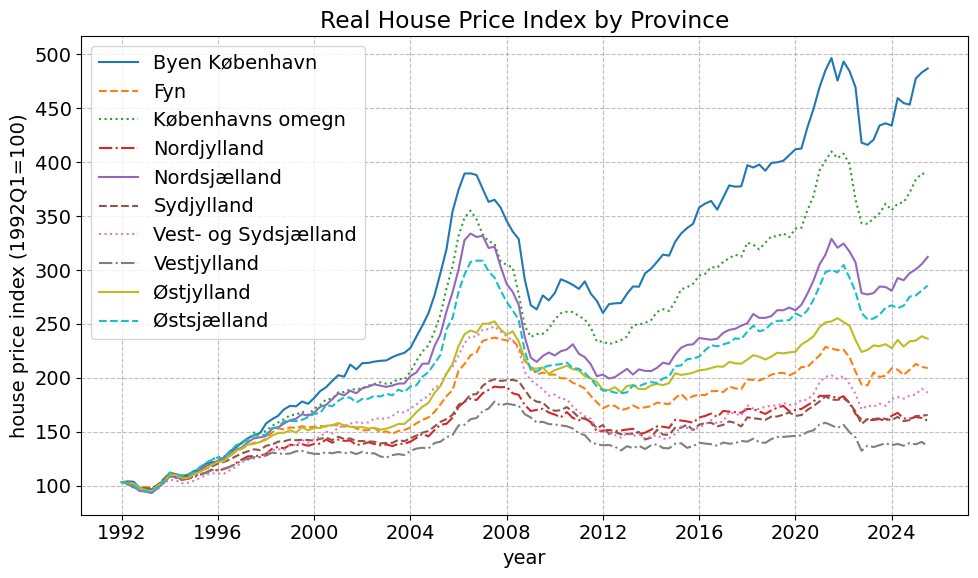

In [16]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)
lss = ['-','--',':','-.']

for i, province in enumerate(df.index.levels[0]):
    ax.plot(df.xs(province).index,df.xs(province).real_house_price_index,label=province, linestyle=lss[i % len(lss)])

ax.legend()
ax.set_ylabel('house price index (1992Q1=100)')
ax.set_xlabel('year')
ax.set_title('Real House Price Index by Province')

fig.tight_layout()

### 1.3. <a id='toc1_3_'></a>[Question 3](#toc0_)

Read in Excel and clean:

In [17]:
# a. load
df = pd.read_excel('BM010_houses.xlsx',skiprows=2)

# b. drop and rename
drop_cols = [f'Unnamed: {num}' for num in range(2)]
df = df.drop(columns=drop_cols)
df = df.rename(columns={'Unnamed: 2': 'municipality'})

# c. stubs
col_dict = {str(i): f'house_price{i}' for i in df.columns[1:]}
df = df.rename(columns=col_dict)
df = df.replace('..','NaN')

# d. convert date wide to long
df_long = df.melt(
    id_vars=['municipality'],
    var_name="time",
    value_name="house_price"
)

# e. time
df_long.time = df_long.time.str.replace('house_price','')
df_long.time = df_long.time.apply(convert_date)
df_long.time = pd.to_datetime(df_long.time)

# f. house price to float
df_long.house_price = df_long.house_price.astype(float)

# g. drop any municipality with nan
df_long = df_long.sort_values(['municipality','time'])
I = df_long.groupby('municipality').house_price.transform(lambda x: x.isna().any())
df_long = df_long[~I]

df_long.head(5)

,municipality,time,house_price
67,Aabenraa,1992-01-01,3356.0
165,Aabenraa,1992-04-01,3277.0
263,Aabenraa,1992-07-01,3079.0
361,Aabenraa,1992-10-01,3178.0
459,Aabenraa,1993-01-01,3306.0


Calculations:

In [18]:
df_long = df_long.reset_index().sort_values(['municipality','time'])

first = df_long.groupby('municipality').house_price.first()
last = df_long.groupby('municipality').house_price.last()
growth = (last - first) / first * 100

Plot:

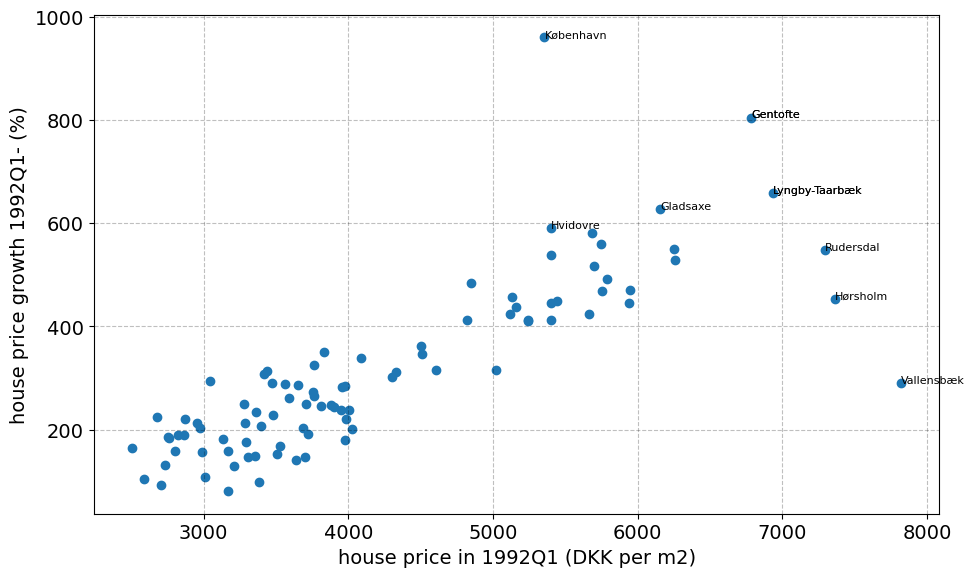

In [19]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(1,1,1)

ax.scatter(first,growth)

# add labels for 5 largest first prices
top_5 = first.sort_values(ascending=False).head(5).index
for municipality in top_5:
    ax.text(first[municipality],growth[municipality],municipality,fontsize=8)

# add labels for 5 largest growth
growth = growth.sort_values(ascending=False)
top_5 = growth.head(5).index
for municipality in top_5:
    ax.text(first[municipality],growth[municipality],municipality,fontsize=8)

ax.set_xlabel('house price in 1992Q1 (DKK per m2)')
ax.set_ylabel('house price growth 1992Q1- (%)')

fig.tight_layout()

### 1.4. <a id='toc1_4_'></a>[Question 4](#toc0_)

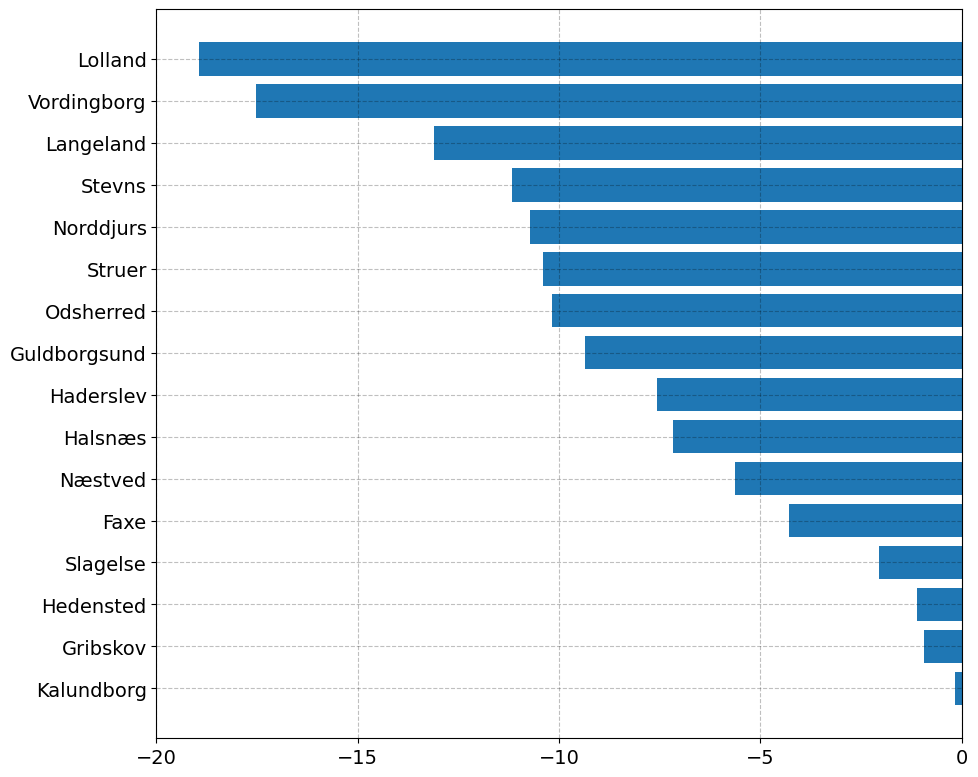

In [20]:
# a. rolling average
df_long['house_price_ra4'] = df_long.groupby('municipality').house_price.transform(lambda x: x.rolling(window=4).mean())

# b. max before 2008 and last
max_house_price_before = df_long[df_long.time < pd.to_datetime('2008-01-01')].groupby('municipality').house_price_ra4.max()
last_house_price = df_long.groupby('municipality').house_price_ra4.last()

# c. change in percentage
pct_change = (last_house_price - max_house_price_before) / max_house_price_before * 100
spct_change = pct_change.sort_values(ascending=False)

# d. horizontal bar plot
K = (spct_change < 0).sum()
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(1,1,1)

ax.barh(spct_change.index[-K:], spct_change.values[-K:])
ax.set_xlim(-20,0)
ax.set_xticks(np.arange(-20,1,5))

fig.tight_layout()

## 2. <a id='toc2_'></a>[Problem 2: Exchange Economy](#toc0_)

In [21]:
from ExchangeEconomyModel_sol import ExchangeEconomyModelClass

In [22]:
model = ExchangeEconomyModelClass()

In [23]:
par = model.par
sol = model.sol

In [24]:
p1_eqs_analytical = [27/64,1,64/27]

### 2.1. <a id='toc2_1_'></a>[Question 1](#toc0_)

In [25]:
def calc_demands(model,m=None):

    # a. number of grid points
    N = 100

    # b. grids
    p1_grid = np.linspace(0.25,5,N)
    x1A_grid = np.zeros(N)
    x1B_grid = np.zeros(N)
    
    # c. compute market clearing errors
    for i,p1 in enumerate(p1_grid):
        x1A_grid[i],_ = model.demand_A(p1,m=m)
        x1B_grid[i],_ = model.demand_B(p1,m=m)
    
    # d. excess demand
    eps1_grid = x1A_grid + x1B_grid - 1.0

    return p1_grid, x1A_grid, x1B_grid, eps1_grid

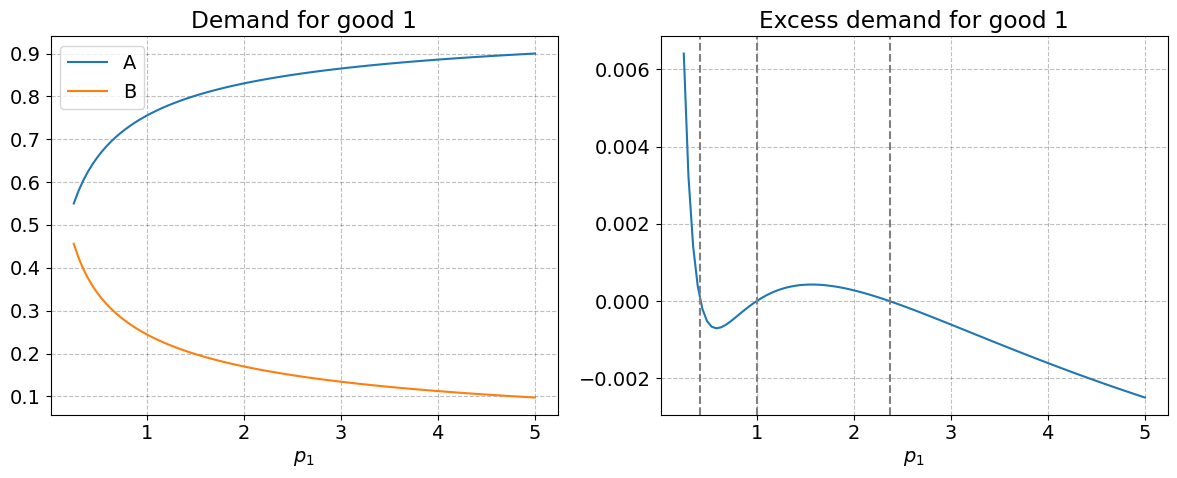

In [26]:
fig = plt.figure(figsize=(12,5))
    
ax = fig.add_subplot(1,2,1)

p1_grid, x1A_grid, x1B_grid, eps1_grid = calc_demands(model)
ax.plot(p1_grid,x1A_grid,'-',label='A')
ax.plot(p1_grid,x1B_grid,'-',label='B')

ax.set_xlabel('$p_1$')
ax.legend()
ax.set_title(fr'Demand for good 1')

ax = fig.add_subplot(1,2,2)
ax.plot(p1_grid,eps1_grid,'-')
ax.set_xlabel('$p_1$')
ax.set_title(fr'Excess demand for good 1')

for p1 in p1_eqs_analytical:
    ax.axvline(p1,linestyle='--',color='gray')

fig.tight_layout()

### 2.2. <a id='toc2_2_'></a>[Question 2](#toc0_)

In [27]:
p1_list = {}
eps1_list = {}

p_guesses = [0.9,1.1]

for p_guess in p_guesses:

    print(f'Solving for p_guess = {p_guess}:')
    model.solve_walras(p_guess,print_output=True)
    p1_list[p_guess] = model.sol.p1_list
    eps1_list[p_guess] = model.sol.eps1_list
    print('')
    

Solving for p_guess = 0.9:
    0: p1 =   0.90000000 -> excess demand of good 1 ->    -0.00018213, x1A =   0.74188153, x2A =   0.23230662, x1B =   0.25793634, x2B =   0.76785729
    1: p1 =   0.89089369 -> excess demand of good 1 ->    -0.00020008, x1A =   0.74058113, x2A =   0.23111464, x1B =   0.25921880, x2B =   0.76906361
    2: p1 =   0.88088977 -> excess demand of good 1 ->    -0.00022001, x1A =   0.73913215, x2A =   0.22979583, x1B =   0.26064784, x2B =   0.77039798
    3: p1 =   0.86988921 -> excess demand of good 1 ->    -0.00024216, x1A =   0.73751355, x2A =   0.22833413, x1B =   0.26224429, x2B =   0.77187652
    4: p1 =   0.85778103 -> excess demand of good 1 ->    -0.00026680, x1A =   0.73570053, x2A =   0.22671108, x1B =   0.26403267, x2B =   0.77351778
    5: p1 =   0.84444120 -> excess demand of good 1 ->    -0.00029419, x1A =   0.73366374, x2A =   0.22490531, x1B =   0.26604207, x2B =   0.77534311
   10: p1 =   0.75395832 -> excess demand of good 1 ->    -0.00048121, x1

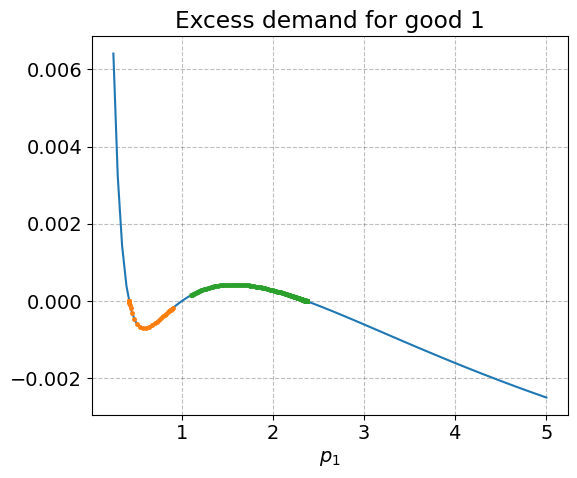

In [28]:
fig = plt.figure(figsize=(6,5))
    
ax = fig.add_subplot(1,1,1)
ax.plot(p1_grid,eps1_grid,'-')
for p_guess in p_guesses:
    ax.plot(p1_list[p_guess],eps1_list[p_guess],ls='',marker='.',markersize=5)
ax.set_xlabel('$p_1$')
ax.set_title(fr'Excess demand for good 1')

fig.tight_layout()

### 2.3. <a id='toc2_3_'></a>[Question 3](#toc0_)

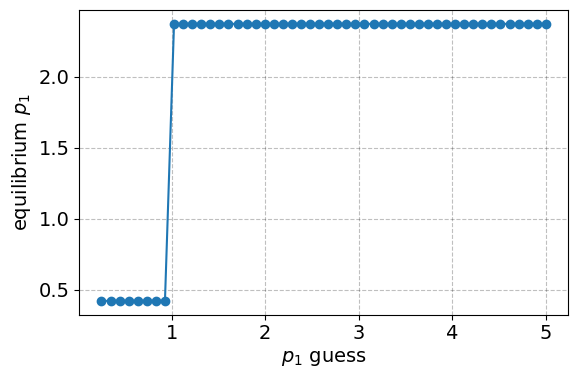

In [29]:
p_guesses = np.linspace(0.25,5.0,50)
p1_eqs = np.zeros_like(p_guesses)
for i,p_guess in enumerate(p_guesses):
    model.solve_walras(p_guess=p_guess,print_output=False)
    p1_eqs[i] = model.sol.p1

fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(1,1,1)
ax.plot(p_guesses,p1_eqs,'-o')
ax.set_xlabel('$p_1$ guess')
ax.set_ylabel('equilibrium $p_1$')

fig.tight_layout()

### 2.4. <a id='toc2_4_'></a>[Question 4](#toc0_)

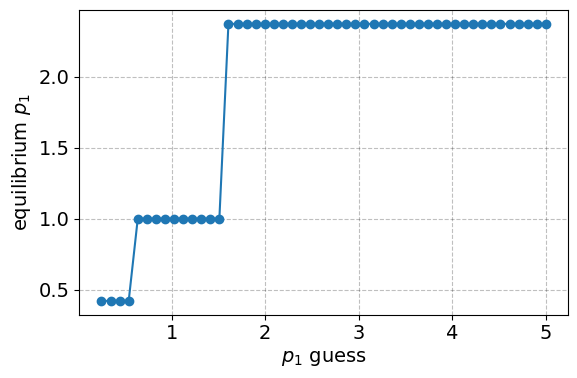

In [30]:
p_guesses = np.linspace(0.25,5.0,50)
p1_eqs = np.zeros_like(p_guesses)
for i,p_guess in enumerate(p_guesses):
    model.solve_walras(p_guess=p_guess,print_output=False,method='newton_raphson')
    p1_eqs[i] = model.sol.p1

fig = plt.figure(figsize=(6,4))

ax = fig.add_subplot(1,1,1)
ax.plot(p_guesses,p1_eqs,'-o')
ax.set_xlabel('$p_1$ guess')
ax.set_ylabel('equilibrium $p_1$')

fig.tight_layout()

### 2.5. <a id='toc2_5_'></a>[Question 5](#toc0_)

    0: p1 =   0.50000000 -> excess demand of good 1 ->    -0.00056100, x1A =   0.66013888, x2A =   0.16993057, x1B =   0.33930012, x2B =   0.83034994
    1: p1 =   0.48527188 -> excess demand of good 1 ->    -0.00049745, x1A =   0.65565274, x2A =   0.16710205, x1B =   0.34384981, x2B =   0.83313935
    2: p1 =   0.47500738 -> excess demand of good 1 ->    -0.00044358, x1A =   0.65242778, x2A =   0.16509937, x1B =   0.34712864, x2B =   0.83511133
    3: p1 =   0.46717675 -> excess demand of good 1 ->    -0.00039658, x1A =   0.64991059, x2A =   0.16355364, x1B =   0.34969283, x2B =   0.83663163
    4: p1 =   0.46092927 -> excess demand of good 1 ->    -0.00035511, x1A =   0.64786571, x2A =   0.16230900, x1B =   0.35177917, x2B =   0.83785468
    5: p1 =   0.45580694 -> excess demand of good 1 ->    -0.00031831, x1A =   0.64616420, x2A =   0.16128082, x1B =   0.35351749, x2B =   0.83886427
   10: p1 =   0.43982753 -> excess demand of good 1 ->    -0.00018571, x1A =   0.64070597, x2A =   0

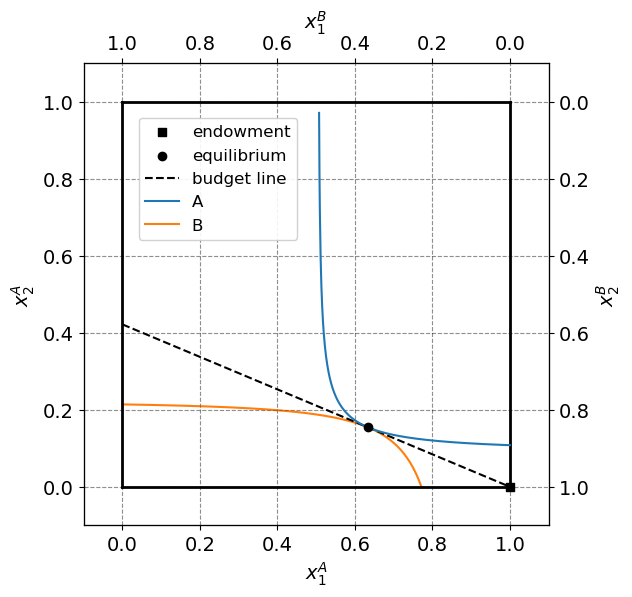


Solved!
     0: p1 =   1.00000000, x1A =   0.75510204, x2A =   0.24489796
 Excess demand of good 1:    -0.00000000
 Excess demand of good 2:     0.00000000


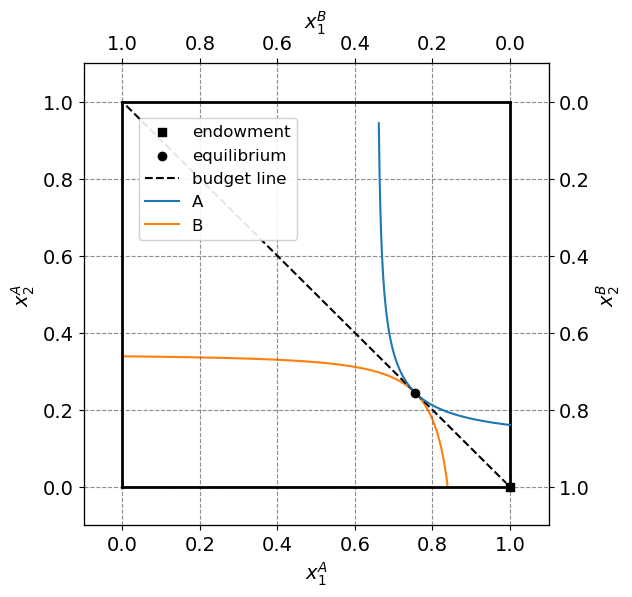

    0: p1 =   2.00000000 -> excess demand of good 1 ->     0.00028050, x1A =   0.83034994, x2A =   0.33930012, x1B =   0.16993057, x2B =   0.66013888
    1: p1 =   2.04550732 -> excess demand of good 1 ->     0.00025149, x1A =   0.83245239, x2A =   0.34271986, x1B =   0.16779911, x2B =   0.65676571
    2: p1 =   2.08373500 -> excess demand of good 1 ->     0.00022572, x1A =   0.83416702, x2A =   0.34555197, x1B =   0.16605870, x2B =   0.65397769
    3: p1 =   2.11644360 -> excess demand of good 1 ->     0.00020272, x1A =   0.83559841, x2A =   0.34794668, x1B =   0.16460431, x2B =   0.65162427
    4: p1 =   2.14476260 -> excess demand of good 1 ->     0.00018215, x1A =   0.83681208, x2A =   0.34999933, x1B =   0.16337007, x2B =   0.64961000
    5: p1 =   2.16948167 -> excess demand of good 1 ->     0.00016372, x1A =   0.83785265, x2A =   0.35177570, x1B =   0.16231107, x2B =   0.64786912
   10: p1 =   2.25566359 -> excess demand of good 1 ->     0.00009630, x1A =   0.84135002, x2A =   0

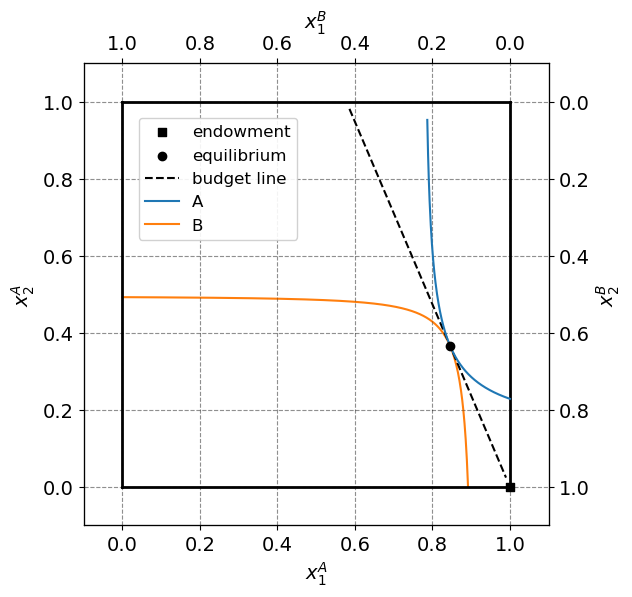

In [31]:
for p1 in [0.5,1.0,2.0]:

    model.solve_walras(p_guess=p1,print_output=True,method='newton_raphson')

    fig,ax_A,ax_B = model.create_edgeworthbox()

    ax_A.scatter(par.w1A,par.w2A,marker='s',color='black',label='endowment',zorder=3)
    ax_A.scatter(sol.xA[0],sol.xA[1],marker='o',color='black',label='equilibrium',zorder=3)

    model.plot_budget_line(ax_A)
    model.indifference_curve_A(ax_A,sol.xA[0],sol.xA[1],color=colors[0],label='A')
    model.indifference_curve_B(ax_B,1-sol.xA[0],1-sol.xA[1],color=colors[1],label='B')
    model.add_legend(ax_A,ax_B)

    plt.show()


## 3. <a id='toc3_'></a>[Problem 3: AS-AD Model](#toc0_)

In [32]:
from ASADModel_sol import ASADModelClass

In [33]:
model = ASADModelClass()

### 3.1. <a id='toc3_1_'></a>[Question 1](#toc0_)

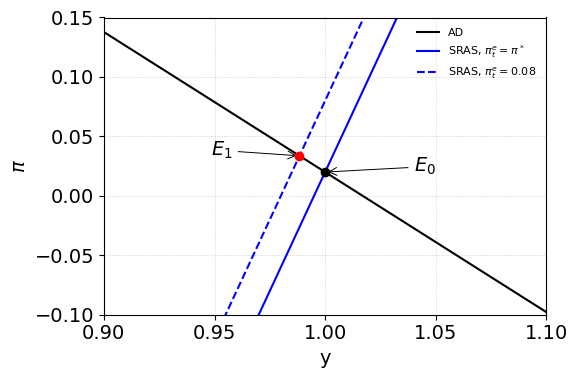

Baseline equilibrium (v=0, pi_e=pi*): y*=1.0000, pi*=0.0200
New SRAS with pi_e=0.08:              y*=0.9884, pi*=0.0336


In [34]:
p = model.par
ygrid = np.linspace(p['ybar'] - 0.10, p['ybar'] + 0.10, 400)

# a. baseline equilibrium
y0, pi0 = model.equilibrium(pi_e=p['pi_star'],v=0.0)
pi_AD0 = model.AD_curve(ygrid,v=0.0)
pi_SRAS0 = model.SRAS_curve(ygrid,pi_e=p['pi_star'])

# b. new SRAS with higher expected inflation
pi_e_new = 0.08
y1, pi1 = model.equilibrium(pi_e=pi_e_new,v=0.0)
pi_SRAS1 = model.SRAS_curve(ygrid,pi_e=pi_e_new)

# c. plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ygrid, pi_AD0, 'k-', label='AD')
ax.plot(ygrid, pi_SRAS0, 'b-', label=r'SRAS, $\pi_t^e=\pi^*$')
ax.plot(ygrid, pi_SRAS1, 'b--', label=r'SRAS, $\pi_t^e=0.08$')

# equilibrium points
ax.scatter([y0], [pi0], c='k', zorder=5)
ax.scatter([y1], [pi1], c='r', zorder=5)

# annotate equilibria
ax.annotate(r'$E_0$', xy=(y0, pi0),
            xytext=(y0+0.04, pi0),
            arrowprops=dict(arrowstyle='->', lw=0.7))

ax.annotate(r'$E_1$', xy=(y1, pi1),
            xytext=(y1-0.04, pi1),
            arrowprops=dict(arrowstyle='->', lw=0.7))

ax.set_xlim(p['ybar'] - 0.10, p['ybar'] + 0.10)
ax.set_ylim(-0.10, 0.15)
ax.set_xlabel('y')
ax.set_ylabel(r'$\pi$')

# smaller legend
ax.legend(loc='upper right', fontsize=8, frameon=False)
ax.grid(True,linestyle=':',linewidth=0.5)
fig.tight_layout()
plt.show()

print(f'Baseline equilibrium (v=0, pi_e=pi*): y*={y0:.4f}, pi*={pi0:.4f}')
print(f'New SRAS with pi_e=0.08:              y*={y1:.4f}, pi*={pi1:.4f}')

### 3.2. <a id='toc3_2_'></a>[Question 2](#toc0_)

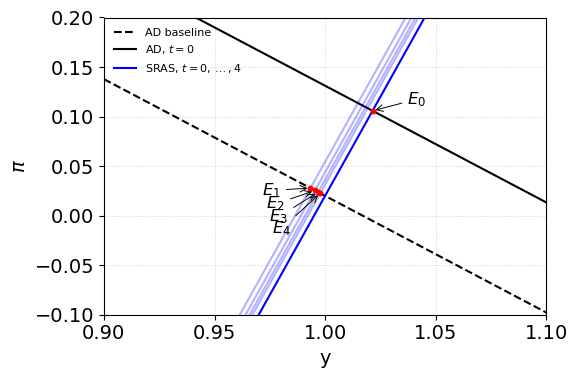

In [35]:
# a. setup
T = 5
v = np.zeros(T)
v[0] = 0.1

# b. allocate
pi_e = np.empty(T)
y_star_T = np.empty(T)
pi_star_T = np.empty(T)

# c. simulate 
pi_e[0] = p['pi_star']
for t in range(T):
    
    if t > 0:
        pi_e[t] = p['phi'] * pi_e[t-1] + (1 - p['phi']) * pi_star_T[t-1]
    
    y_star_T[t], pi_star_T[t] = model.equilibrium(pi_e[t], v[t])

# a. plot
ygrid = np.linspace(p['ybar'] - 0.10, p['ybar'] + 0.10, 400)

fig, ax = plt.subplots(figsize=(6, 4))

# AD
pi_ad_base = model.AD_curve(ygrid, 0.0)
ax.plot(ygrid, pi_ad_base, 'k--', label='AD baseline')

pi_ad_v0 = model.AD_curve(ygrid, v[0])
ax.plot(ygrid, pi_ad_v0,   'k-',  label='AD, $t=0$')

# SRAS
for t in range(T):

    pi_SRAS_t = model.SRAS_curve(ygrid, pi_e[t])
    if t == 0:
        ax.plot(ygrid, pi_SRAS_t, 'b-', label=r'SRAS, $t=0,\dots,4$')
    else:
        ax.plot(ygrid, pi_SRAS_t, 'b-', alpha=0.3)

# equilibria
for t in range(T):

    ax.scatter(y_star_T[t], pi_star_T[t], c='r', s=10, zorder=5)
    
    if t == 0:
        ax.annotate(r'$E_0$',
                    xy=(y_star_T[t], pi_star_T[t]),
                    xytext=(25, 5),
                    textcoords='offset points',
                    fontsize=12,
                    arrowprops=dict(arrowstyle='->', lw=0.7))
    else:
        ax.annotate(fr'$E_{t}$',
                    xy=(y_star_T[t], pi_star_T[t]),
                    xytext=(-35, -5 - 8*(t-1)),   # stack labels nicely
                    textcoords='offset points',
                    fontsize=12,
                    arrowprops=dict(arrowstyle='->', lw=0.7))

# axis limits and labels
ax.set_xlim(p['ybar'] - 0.10, p['ybar'] + 0.10)
ax.set_ylim(-0.10, 0.20)
ax.set_xlabel('y')
ax.set_ylabel(r'$\pi$')
ax.legend(loc='upper left', fontsize=8, frameon=False)
ax.grid(True, linestyle=':', linewidth=0.5)

fig.tight_layout()

### 3.3. <a id='toc3_3_'></a>[Question 3](#toc0_)

rho = 0.8: sd(y) = 0.0026, sd(pi) = 0.0155, corr(y,pi) = 0.5449
rho = 0.5: sd(y) = 0.0024, sd(pi) = 0.0105, corr(y,pi) = 0.7340


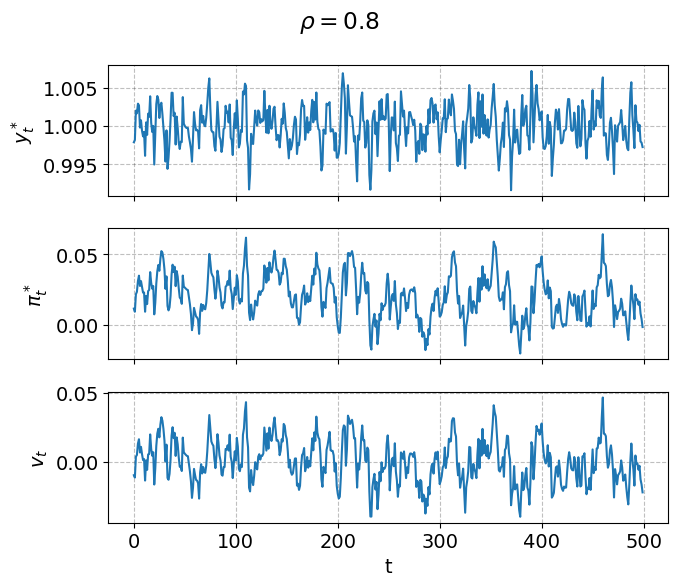

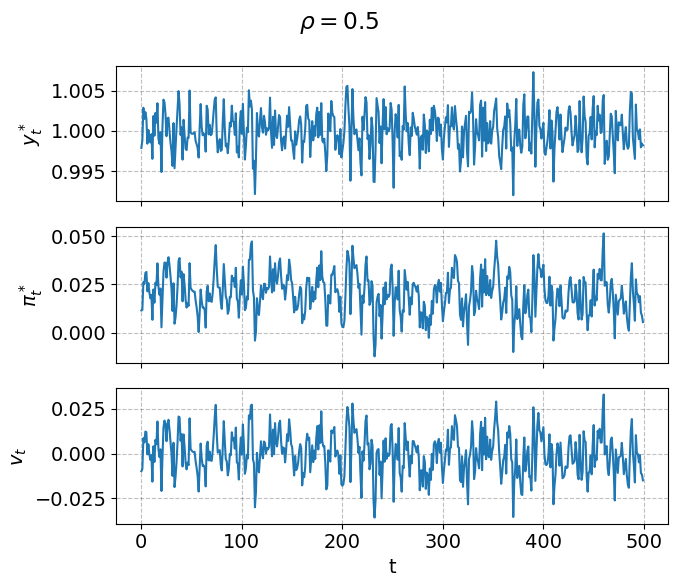

In [36]:
# a. draw shocks
T = 500
rng = np.random.default_rng(123)
eps = rng.normal(0.0, 0.01, size=T) # same shocks for both rho

# b. simulate
y08, pi08, v08 = model.simulate(rho=0.8, eps=eps)
y05, pi05, v05 = model.simulate(rho=0.5, eps=eps)

# c. compute moments
sd_y08, sd_pi08, corr08 = model.moments(y08, pi08)
sd_y05, sd_pi05, corr05 = model.moments(y05, pi05)

print(f'rho = 0.8: sd(y) = {sd_y08:.4f}, sd(pi) = {sd_pi08:.4f}, corr(y,pi) = {corr08:.4f}')
print(f'rho = 0.5: sd(y) = {sd_y05:.4f}, sd(pi) = {sd_pi05:.4f}, corr(y,pi) = {corr05:.4f}')

# plots
def plot_series(y, pi, v, title):
    
    fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
    axes[0].plot(y)
    axes[0].set_ylabel(r'$y_t^*$')
    axes[1].plot(pi)
    axes[1].set_ylabel(r'$\pi_t^*$')
    axes[2].plot(v)
    axes[2].set_ylabel(r'$v_t$')
    axes[2].set_xlabel('t')
    
    fig.suptitle(title)
    fig.tight_layout()

    plt.show()

plot_series(y08, pi08, v08, r'$\rho = 0.8$')
plot_series(y05, pi05, v05, r'$\rho = 0.5$')